# TB Chest X-ray - OpenCV Preprocessing

This notebook walks through the image pipeline built with **OpenCV** in
`src/preprocessing.py`. It is intentionally short: load, enhance, resize,
normalize, and finally see what tensor the model actually receives.

## 1. Setup

Run from the project root so the `src/` modules can be imported.

In [1]:
import os
import sys

ROOT = os.getcwd()
if not os.path.isfile(os.path.join(ROOT, "config.yaml")):
    ROOT = os.path.dirname(ROOT)
os.chdir(ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))

import cv2
import matplotlib.pyplot as plt

from data import XRayDataset, load_config, load_metadata
import preprocessing as pp

cfg = load_config("config.yaml")
df = load_metadata(cfg["data"]["root"])
print("config:", cfg["preprocess"])

config: {'use_clahe': True, 'clahe_clip': 1.0, 'clahe_tile': 8}


## 2. Loading images with OpenCV

X-rays are grayscale. `read_gray()` decodes them directly into a single
channel uint8 array so there is no wasted RGB conversion.

In [2]:
normal_path = os.path.join(cfg["data"]["root"], "normal/Normal-1.png")
tb_path = os.path.join(cfg["data"]["root"], "tuberculosis/Tuberculosis-1.png")

normal = pp.read_gray(normal_path)
tb = pp.read_gray(tb_path)
print("Normal image:", normal.shape, normal.dtype)
print("TB image:    ", tb.shape, tb.dtype)

Normal image: (256, 256) uint8
TB image:     (256, 256) uint8


## 3. The pipeline, step by step

1. **CLAHE** - equalize local contrast so faint lesions stand out,
2. **Resize** - downscale to one fixed square size,
3. **Normalize** - scale pixel values to `[0, 1]` and add a channel dim.

In [3]:
image = pp.read_gray(tb_path)
print("1. read_gray   ->", image.shape, image.dtype)

image = pp.apply_clahe(image, cfg["preprocess"]["clahe_clip"], cfg["preprocess"]["clahe_tile"])
print("2. apply_clahe ->", image.shape, image.dtype)

image = pp.resize(image, cfg["image_size"])
print("3. resize      ->", image.shape, image.dtype)

tensor = pp.to_tensor(image)
print("4. to_tensor   ->", tuple(tensor.shape), tensor.dtype, tensor.min().item(), "-", tensor.max().item())

1. read_gray   -> (256, 256) uint8
2. apply_clahe -> (256, 256) uint8
3. resize      -> (128, 128) uint8
4. to_tensor   -> (1, 128, 128) torch.float32 0.11372549086809158 - 0.9725490212440491


## 4. Why CLAHE instead of plain equalization?

Global histogram equalization can wash out local detail. CLAHE works on
small tiles, which keeps soft tissue contrast in place while brightening
the lung areas where TB lesions usually live.

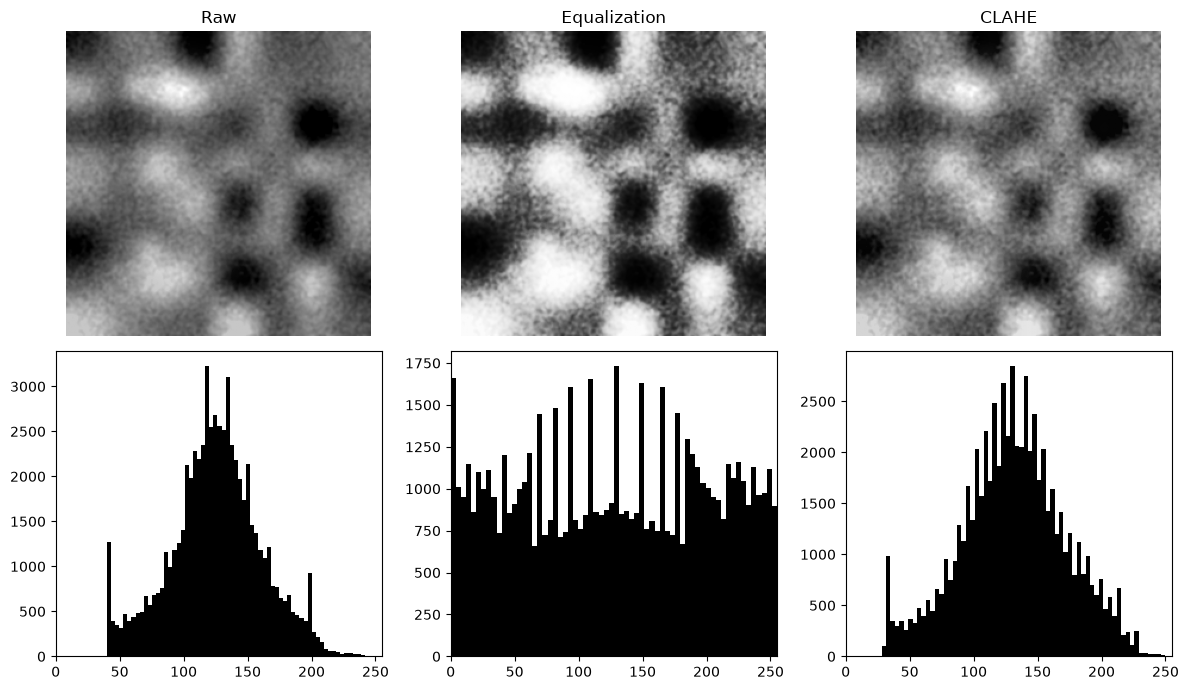

In [4]:
def histogram(image, ax):
    ax.hist(image.ravel(), bins=64, color="black")
    ax.set_xlim(0, 255)

raw = pp.read_gray(tb_path)
equ = cv2.equalizeHist(raw)
clahe = pp.apply_clahe(raw, cfg["preprocess"]["clahe_clip"], cfg["preprocess"]["clahe_tile"])

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, image, title in zip(axes[0], (raw, equ, clahe), ("Raw", "Equalization", "CLAHE")):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
for ax, image in zip(axes[1], (raw, equ, clahe)):
    histogram(image, ax)
plt.tight_layout()
plt.show()

## 5. What the model actually sees

`XRayDataset` runs the same pipeline for every image, so each sample is a
`1 x size x size` float tensor in `[0, 1]` - exactly what the small CNN
in `src/model.py` expects.

tensor: (1, 128, 128) torch.float32 0.11764705926179886 - 0.8941176533699036 label: 0


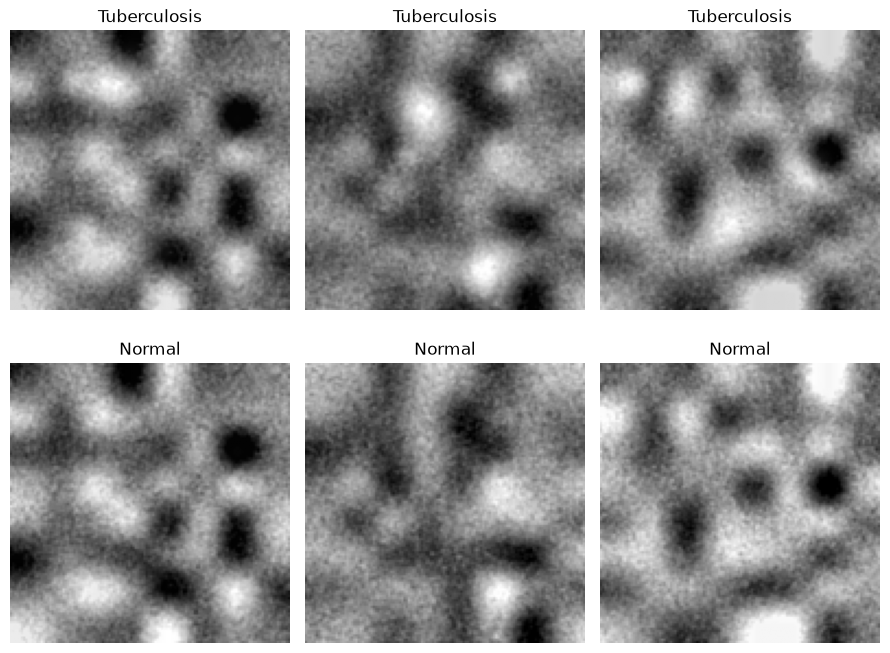

In [5]:
dataset = XRayDataset(df, cfg["data"]["root"], cfg["image_size"], cfg["preprocess"])
x, y = dataset[0]
print("tensor:", tuple(x.shape), x.dtype, x.min().item(), "-", x.max().item(), "label:", y)

tb_idx = df.index[df["label"] == "Tuberculosis"][:3].tolist()
normal_idx = df.index[df["label"] == "Normal"][:3].tolist()

fig, axes = plt.subplots(2, 3, figsize=(9, 7))
for ax, idx in zip(axes.flat, tb_idx + normal_idx):
    image, _ = dataset[idx]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(df["label"].iloc[idx])
    ax.axis("off")
plt.tight_layout()
plt.show()